<a href="https://colab.research.google.com/github/Fazal2204/IML-assignment-2/blob/main/Question2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

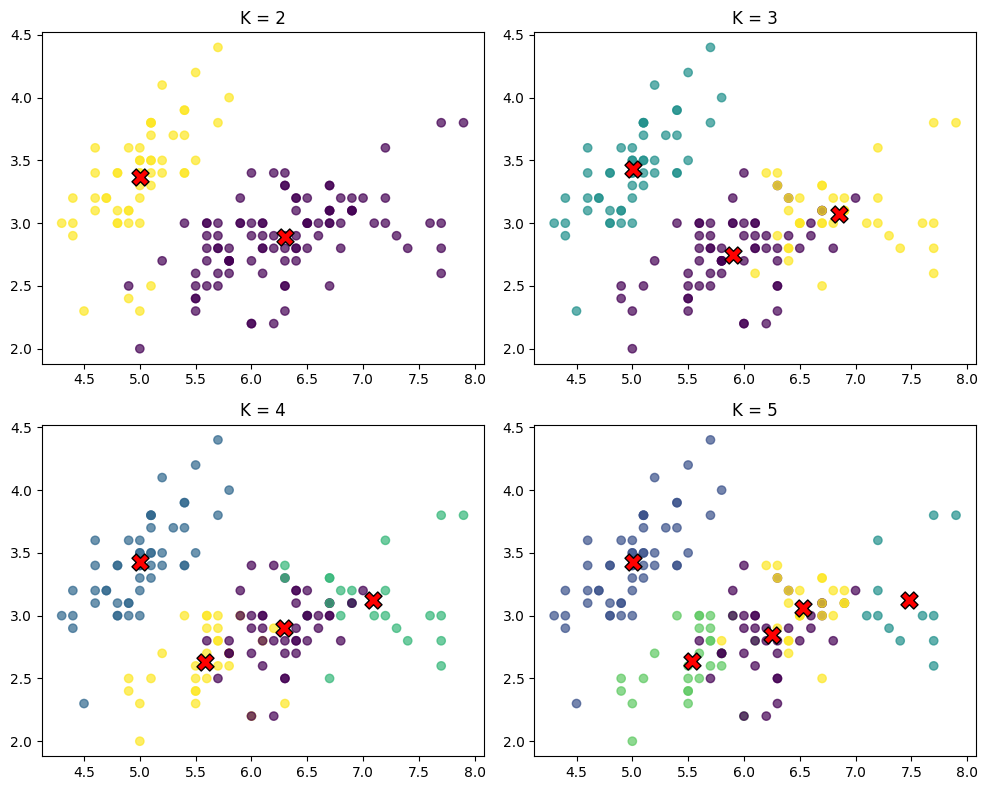

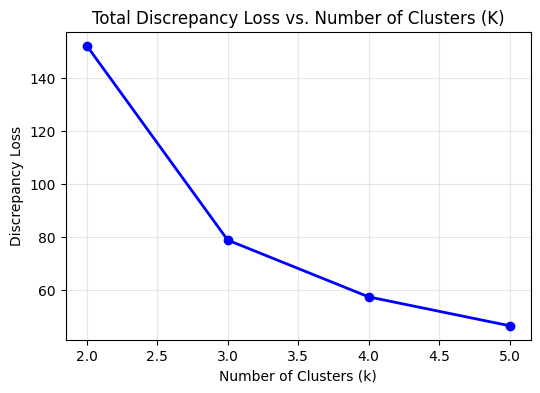

Summary
Ran K-means from scratch testing k = [2, 3, 4, 5]
The calculated losses were: [152.35, 78.85, 57.38, 46.47]
Based on how fast the loss stops dropping after k=3, 3 is the best choice.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data

def run_kmeans(X, k, max_iters=100):
    np.random.seed(42)
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids

    loss = sum(np.sum((X[labels == i] - centroids[i])**2) for i in range(k))
    return labels, centroids, float(loss)

k_values = [2, 3, 4, 5]
losses = []

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, k in zip(axes.ravel(), k_values):
    labels, centers, loss = run_kmeans(X, k)
    losses.append(loss)

    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7)
    ax.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=150, edgecolors='k')
    ax.set_title(f"K = {k}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(k_values, losses, marker='o', color='blue', linewidth=2)
plt.title("Total Discrepancy Loss vs. Number of Clusters (K)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Discrepancy Loss")
plt.grid(True, alpha=0.3)
plt.show()

print("Summary")
print(f"Ran K-means from scratch testing k = {k_values}")
print(f"The calculated losses were: {[round(l, 2) for l in losses]}")
print("Based on how fast the loss stops dropping after k=3, 3 is the best choice.")

Findings:

When I ran the algorithm and plotted the discrepancy loss for each k, I noticed a massive drop when moving from k=2 to k=3. After k=3, the loss keeps going down (which makes sense mathematically), but the reductions are way smaller and basically level off. Because the loss reduction slows down so much after 3, and we already know the Iris dataset has exactly 3 species of flowers, k=3 is clearly the right answer. If you look at the scatter plots, k=2 awkwardly merges two distinct species together, and k=4 or 5 just start making up fake boundaries where there aren't any.